In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import pandas as pd
from scipy.stats import pearsonr, spearmanr, kendalltau
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import ScalarFormatter
import sys
from matplotlib import gridspec
sys.path.insert(1,'../4. CompareNormalisation')

from Functions import *
import MetricMapping


# Access the mappings:
type_mapping = MetricMapping.type_mapping
name_mapping = MetricMapping.name_mapping

In [2]:
datadir = '/scratch/hydro4/users/kv25483/MetricEvaluation/Data/IntermediateFiles/'
figdir = '/scratch/hydro4/users/kv25483/MetricEvaluation/Figures/'

### Read in data

In [3]:
justraw = pd.read_csv(datadir+"Justraw.csv")

#### Delineate categorical and continuous metrics

In [4]:
metrics = list(name_mapping.keys())
categorical_metrics = ['3rd_ARR',  '3rd_rcg',  '3rd_w_most', 
                       '4th_w_most', '5th_w_most', 'third_ppr', '3rd_w_peak', '4th_w_peak', '5th_w_peak', ]
continuous_metrics = [metric for metric in list(type_mapping.keys()) if metric not in categorical_metrics]

# categorical_metrics = categorical_metrics = [col + '_raw' for col in categorical_metrics]
# continuous_metrics = continuous_metrics = [col + '_raw' for col in continuous_metrics]

In [5]:
# cols_to_delete = [f'{var}_{res}'
#     for var in ['total_precip'] 
#     for res in ['5m', '10m', '30m', '60m']]

# transformed_minmax_scaled.drop(columns=cols_to_delete, inplace=True)

In [6]:
summary_df = compute_metric_sensitivity_by_resolution(df=justraw,
    continuous_metrics=continuous_metrics,
    categorical_metrics=categorical_metrics,
    resolutions=["10m", "30m", "60m"])

summary_df['metric'] = summary_df['metric'].str.replace(r'_raw$', '', regex=True)
summary_df["type2"] = summary_df["metric"].map(type_mapping)

/scratch/hydro4/users/kv25483/MetricEvaluation/Scripts/5. CompareResolutions/../4. CompareNormalisation/Functions.py:111: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rank_corr, _ = spearmanr(x, y)


In [7]:
df_continuous = summary_df[summary_df["type"] != "categorical"]
unique_metrics_continuous = df_continuous["metric"].unique()

df_categorical = summary_df[summary_df["type"] == "categorical"]
unique_metrics_categorical = df_categorical["metric"].unique()

### Plot

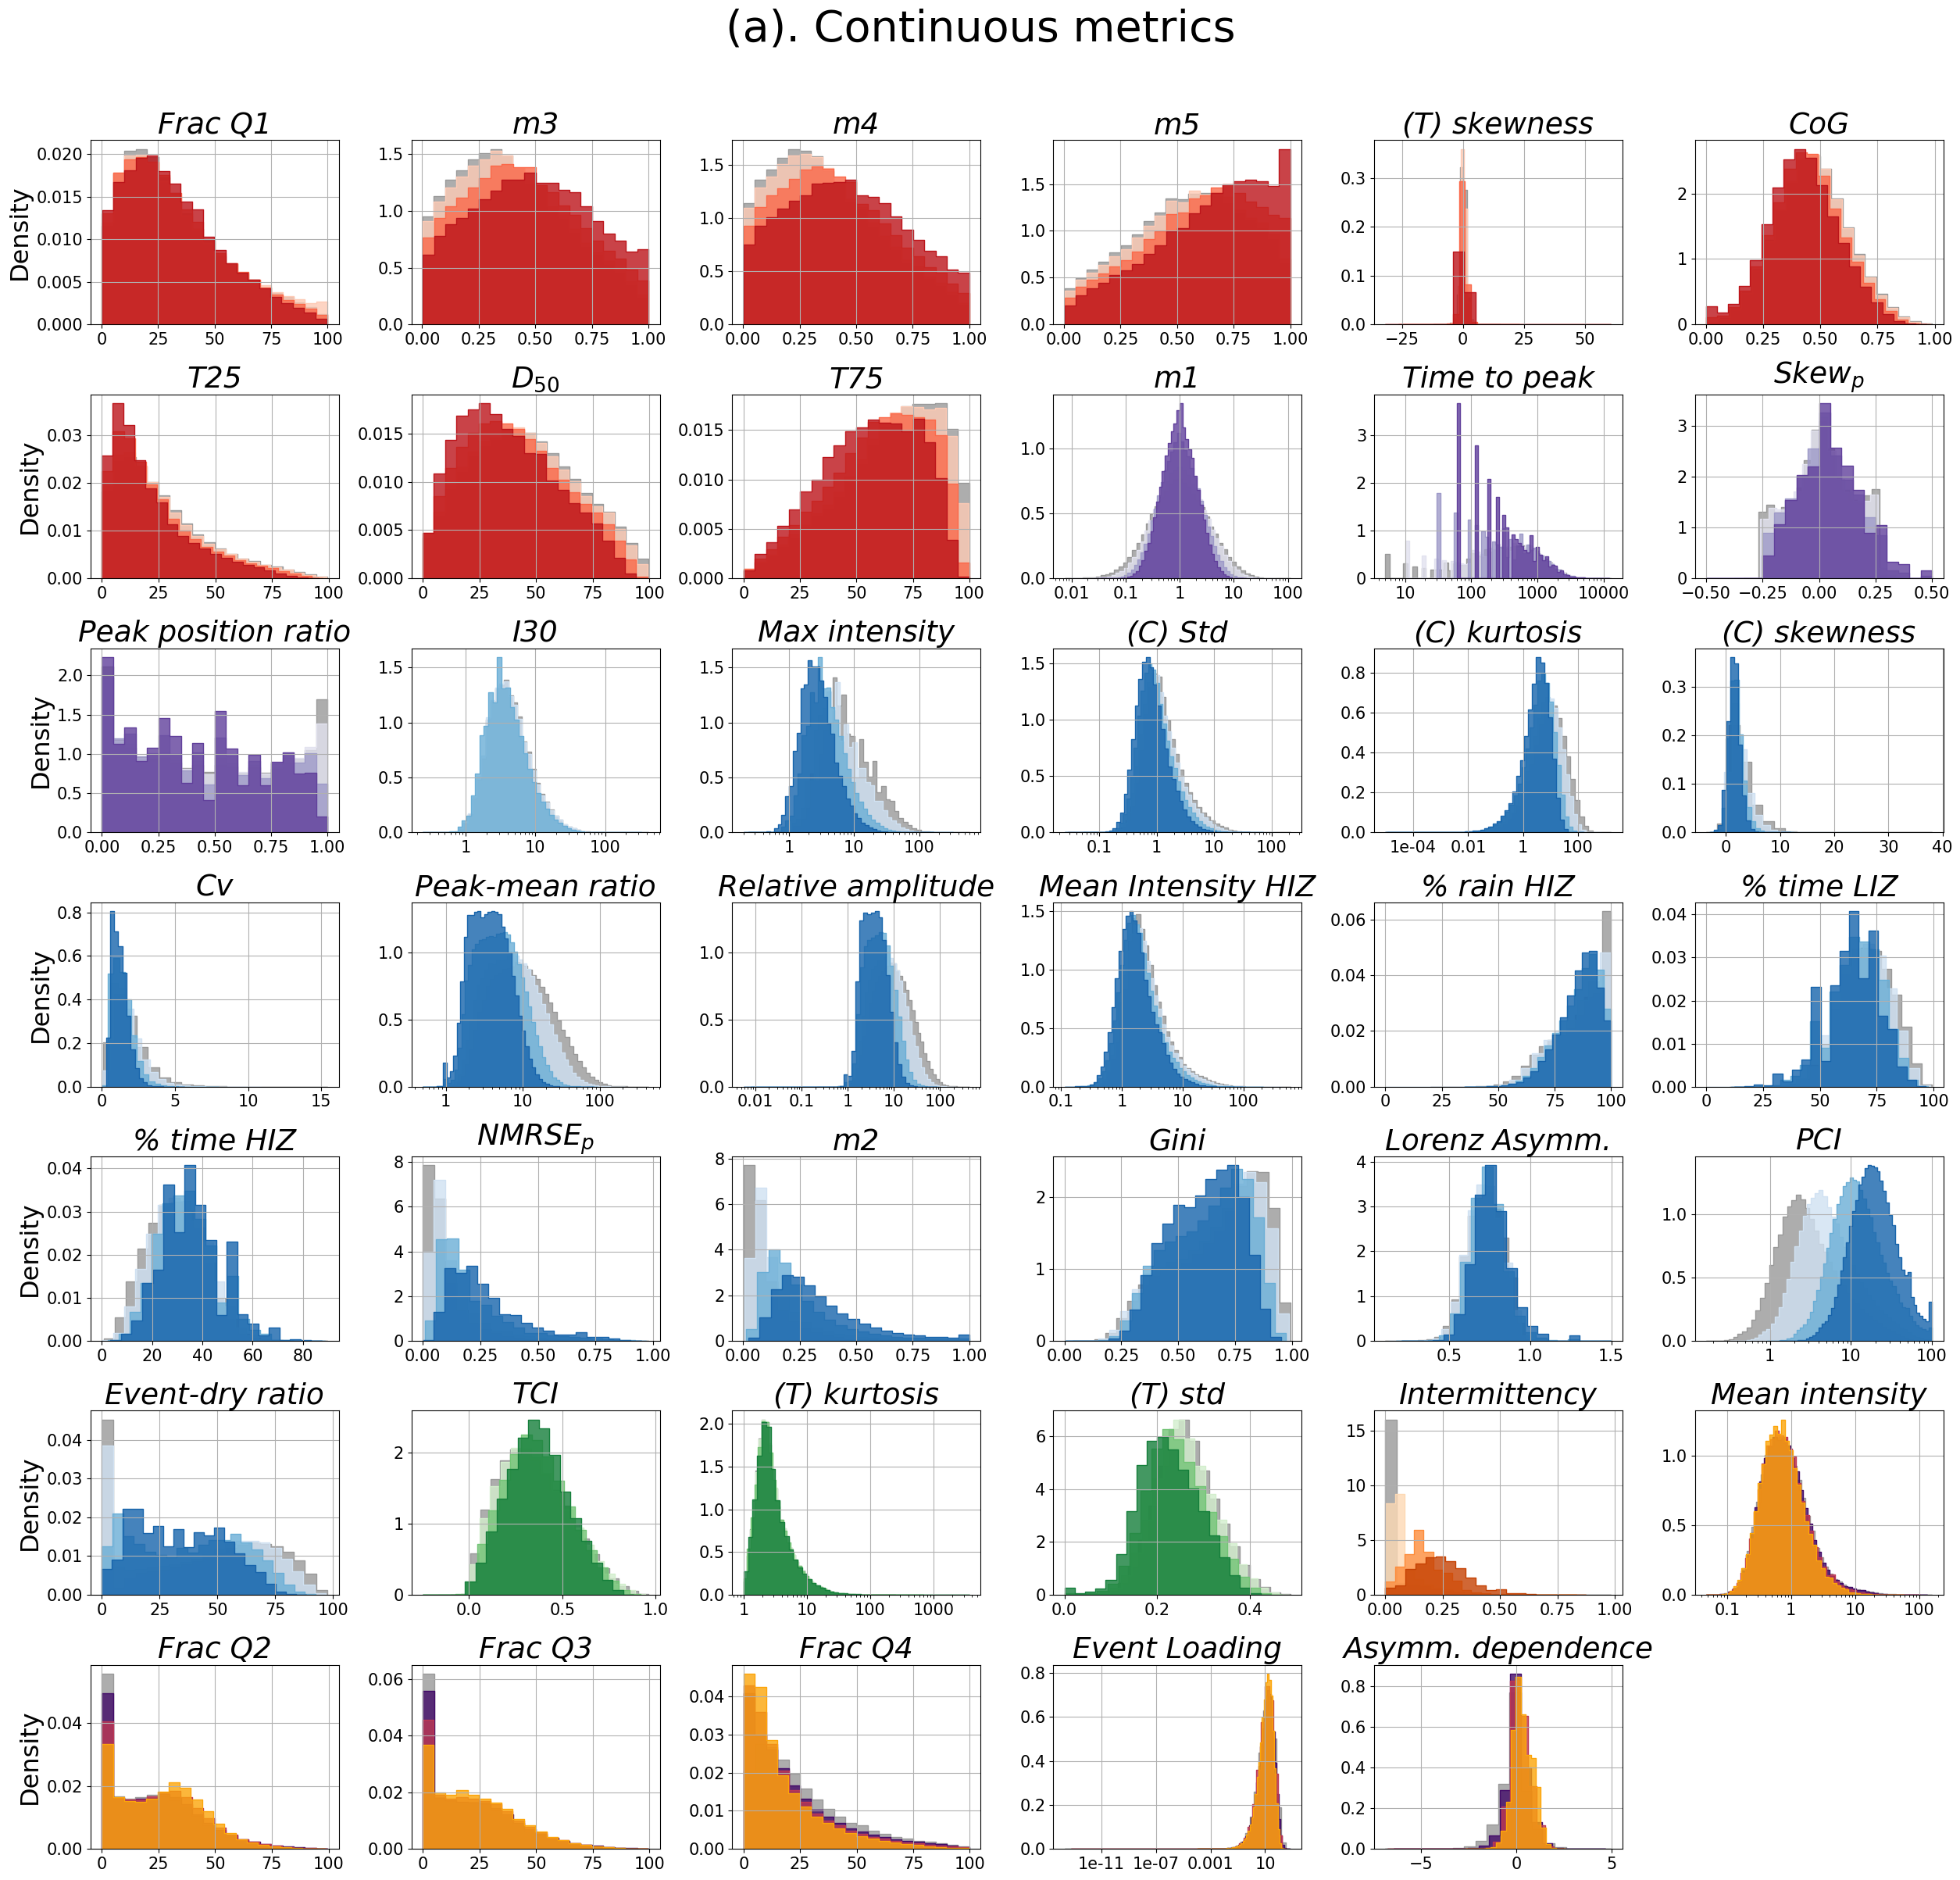

In [8]:
resolutions = ['5m', '10m', '30m', '60m']

log_x_metrics = ['m1', 'm1_wi', 'mean_intensity', 'max_intensity', 'time_kurtosis', 'time_to_peak', 'PCI',
                'kurtosis', 'Mean Intensity HIZ', 'I30', 'std', 'peak_mean_ratio', 'Event Loading', 'relative_amp',
                'time_std']

n_cols_main = 6
n_rows_main = -(-len(unique_metrics_continuous) // n_cols_main)

fig_main, axs_main = plt.subplots(ncols=n_cols_main, nrows=n_rows_main,
                                  figsize=(4.2 * n_cols_main, 3.5 * n_rows_main),
                                  sharex=False, sharey=False)
axs_main = axs_main.flatten()

# Track max/min values for autoscaled limits
x_min, x_max, y_min, y_max = float('inf'), float('-inf'), float('inf'), float('-inf')

for i, this_metric in enumerate(unique_metrics_continuous):
    ax = axs_main[i]
    metric_data = df_continuous[df_continuous["metric"] == this_metric]
        
    plot_histograms(ax,justraw, this_metric, metric_data, log_x_metrics, type_color_map_1, resolutions)

    # Update global x/y limits
    x_vals = metric_data["rank_corr"]
    y_vals = metric_data["val_diff"]
    if not x_vals.empty and not y_vals.empty:
        x_min = min(x_min, x_vals.min())
        x_max = max(x_max, x_vals.max())
        y_min = min(y_min, y_vals.min())
        y_max = max(y_max, y_vals.max())

for ax in axs_main[len(unique_metrics_continuous):]:
    ax.axis('off')
    
for i, ax in enumerate(axs_main):
    if i % n_cols_main == 0:  # First column in each row
        ax.set_ylabel('Density', fontsize=23)
    else:
        ax.set_ylabel('')            
    
# fig_main.suptitle("Summary statistics (Asymmetry, Peakiness, Concentration)", fontsize=25)
fig_main.suptitle("(a). Continuous metrics", fontsize=40)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

fig_main.savefig(figdir+"CompareResolutions/histogram_continuous_metrics.png", dpi=300, facecolor='white')

### Categorical metrics

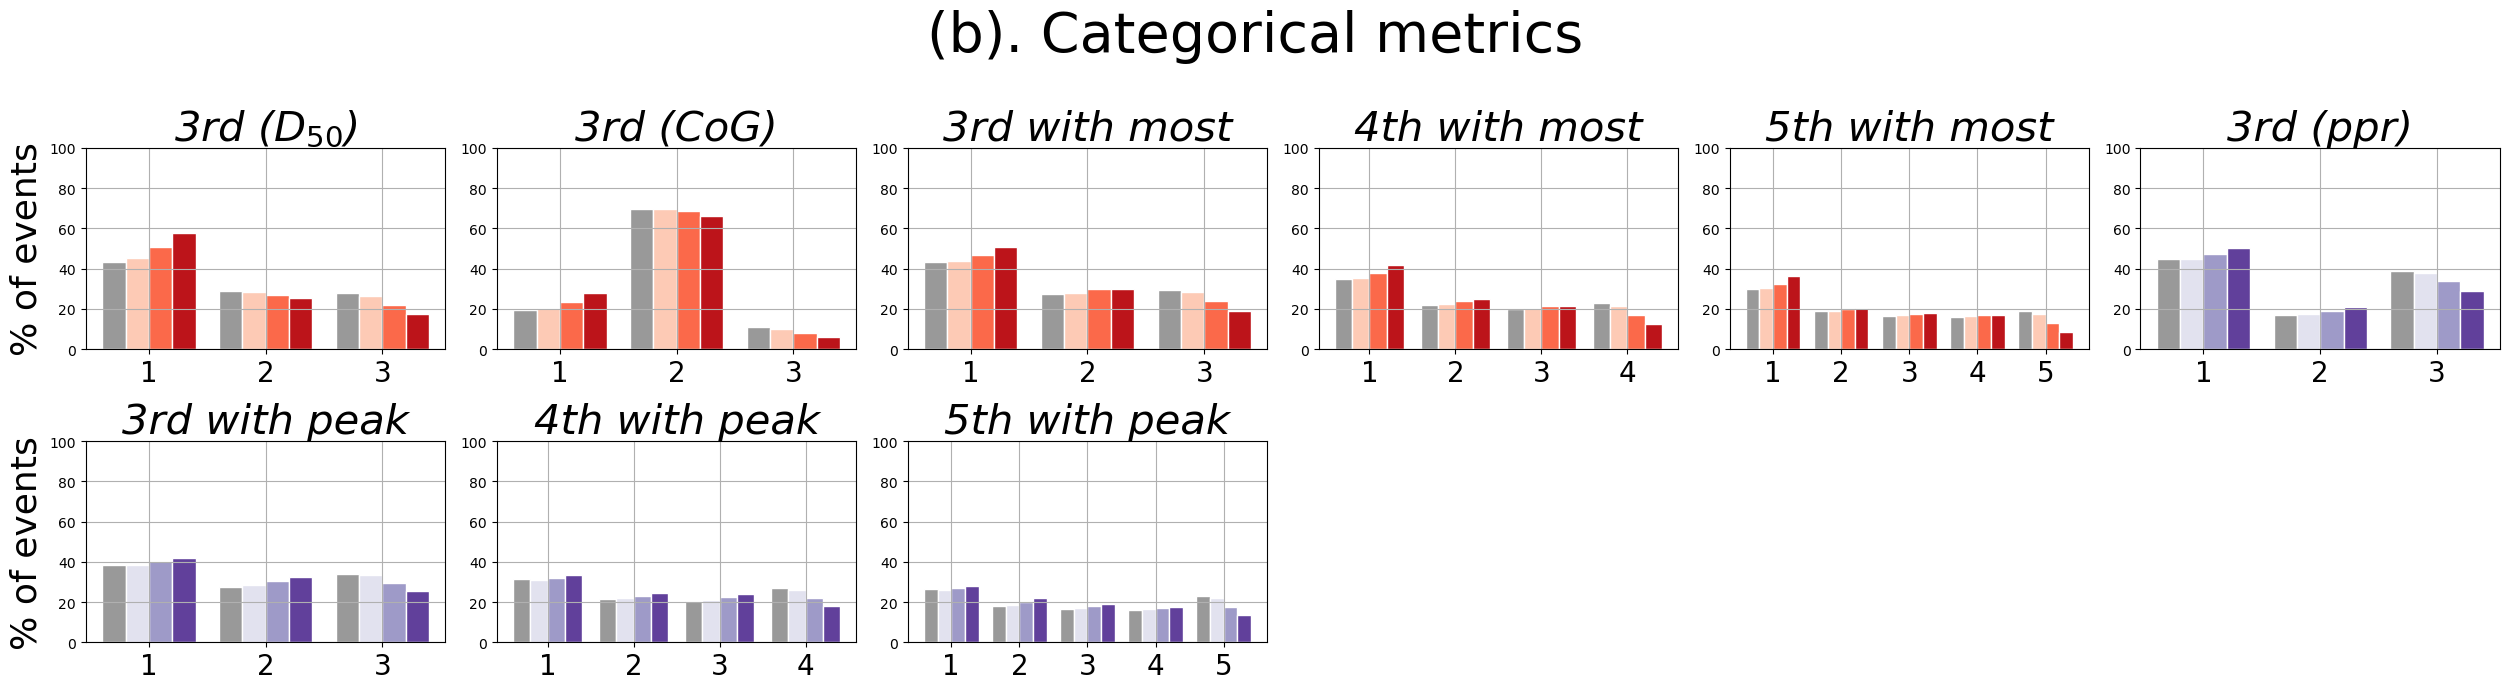

In [9]:
n_cols = 6
n_rows = -(-len(unique_metrics_categorical) // n_cols)
fig, axs = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=(4.2 * n_cols, 3.5 * n_rows), sharex=False, sharey=False)
axs = axs.flatten()

for i, metric in enumerate(unique_metrics_categorical):
    metric_data = df_categorical[df_categorical["metric"] == metric]
    plot_grouped_categorical(
        axs[i],
        metric,
        metric_data , justraw,         
        type_color_map_1, resolutions)

# turn off any unused axes
for ax in axs[len(unique_metrics_categorical):]:
    ax.axis('off')

for i, ax in enumerate(axs):
    if i % n_cols == 0:  # First column in each row
        ax.set_ylabel('% of events', fontsize=26)
    else:
        ax.set_ylabel('')    

# fig.suptitle("../Figures/Categorical metrics", fontsize=25)
fig.suptitle("(b). Categorical metrics", fontsize=40)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
fig.savefig(figdir+"CompareResolutions/histogram_categorical_metrics.png", dpi=300, facecolor='white')

### Create legend

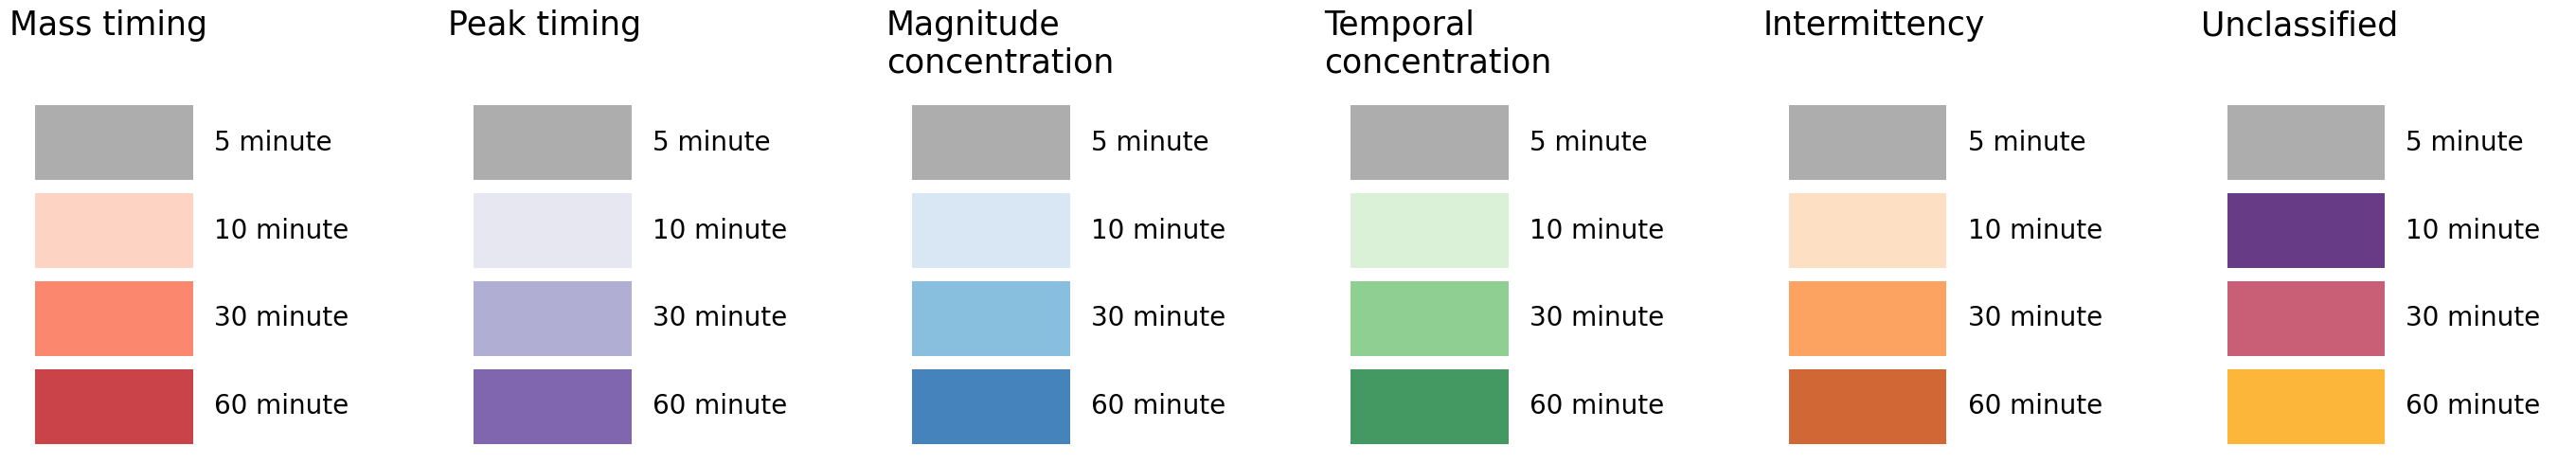

In [10]:
legend_types = list(type_color_map_1.keys())
labels = ['5 minute', '10 minute', '30 minute', '60 minute']

fig_leg, axs_leg = plt.subplots(ncols=len(legend_types),figsize=(5 * len(legend_types), 2))

if len(legend_types) == 1:
    axs_leg = [axs_leg]

for ax, metric_type in zip(axs_leg, legend_types):

    ax.axis("off")

    colors = type_color_map_1[metric_type]

    patches = [Patch(facecolor=colors[j], label=labels[j], alpha=0.8)
        for j in range(len(resolutions))]
    
    # Handle long titles
    title = metric_type.replace(" ", "\n", 1) if len(metric_type) > 20 else metric_type
    if "\n" not in title:
        title = title + "\n "  # blank second line for spacing

    # Legend without title
    ax.legend(handles=patches, title='',loc="center",frameon=False, fontsize=20, handlelength=6, handleheight=4)

    # Add text above the color boxes
    ax.text(0, 1.9, title, fontsize=25, ha='left', va='bottom', transform=ax.transAxes)

# --- manually adjust top margin so text is not cut off ---
fig_leg.subplots_adjust(top=0.85, left=0.05, right=0.95)  # adjust top, left, right margins
plt.show()
fig_leg.savefig(figdir+"CompareResolutions/histogram_legend.png", dpi=300, facecolor='white', bbox_inches='tight')

### Join the two images

In [11]:
from PIL import Image
import glob

# Collect images
files = sorted(glob.glob(figdir+"CompareResolutions/histogram_continuous_metrics.png")) + \
        sorted(glob.glob(figdir+"CompareResolutions/histogram_categorical_metrics.png")) + \
        sorted(glob.glob(figdir+"CompareResolutions/histogram_legend.png"))

if not files:
    raise ValueError("No images found – check path or extension")

# Open all images
imgs = [Image.open(f).convert("RGB") for f in files]

# Resize to same width if needed
width = max(img.width for img in imgs)
resized = [img if img.width == width else img.resize((width, int(img.height * width / img.width)))
           for img in imgs]

# Add extra spacing after the 2nd image
spacing_after_second = 210  # pixels

# Compute total height
total_height = sum(img.height for img in resized) + spacing_after_second+ spacing_after_second

# Create canvas
canvas = Image.new("RGB", (width, total_height), (255, 255, 255))

# Paste images with spacing
y = 0
for i, img in enumerate(resized):
    canvas.paste(img, (0, y))
    y += img.height
    # add spacing after 2nd image
    if i in [0,1]:
        y += spacing_after_second

canvas.save(figdir+"CompareResolutions/histograms_combined.png", dpi=(300, 300))